# **Model A — 1D CNN on Raw Waveforms (SI Train/Val/Test — 5-Block CV)**
SI Dataset 5-Block Rotating CV (Subject-Level StratifiedKFold) · 1D CNN on raw waveforms


In [52]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os
import json
import random
import copy
import warnings
from pathlib import Path
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import soundfile as sf
import librosa

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve, auc,
    average_precision_score,
)

warnings.filterwarnings('ignore')

print(f'PyTorch: {torch.__version__}')
print(f'Device: {"CUDA" if torch.cuda.is_available() else "CPU"}')

PyTorch: 2.6.0+cu124
Device: CUDA


In [53]:
# ── Global Seed ───────────────────────────────────────────────────────────────
RANDOM_SEED = 42

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [54]:
# ── Configuration ─────────────────────────────────────────────────────────────
BASE_DIR    = Path('..')

# SI data (train / val / test — subject-level 5-block CV)
NON_TB_PATH = BASE_DIR / 'data_root' / 'Cough_sounds_healthy_individuals'
TB_PATH     = BASE_DIR / 'data_root' / 'Cough_sounds_patients_with_ptb'

# Audio
SAMPLE_RATE    = 16000
CLIP_DURATION  = 2
CLIP_LENGTH    = int(SAMPLE_RATE * CLIP_DURATION)

# CV — SI 5-block rotating subject-level StratifiedKFold
N_FOLDS     = 5
RANDOM_SEED = 42

# Training
EPOCHS        = 30
BATCH_SIZE    = 8
LEARNING_RATE = 1e-4
CNN_DROPOUT   = 0.5

# Early stopping
ES_PATIENCE = 10
ES_DELTA    = 0.001

# DataLoader workers
N_DL_WORKERS       = 8
INFERENCE_BATCH_SIZE = 384

OUTPUT_DIR = BASE_DIR / 'output_model_a'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Configuration loaded.')
print(f'DataLoader workers   : {N_DL_WORKERS}')
print(f'Inference batch size : {INFERENCE_BATCH_SIZE}')


Configuration loaded.
DataLoader workers   : 8
Inference batch size : 384


## Load SI Dataset (Train / Val / Test — 5-Block Subject CV)


In [55]:
# ── Load SI data from directory scan ─────────────────────────────────────────
def scan_audio(directory: Path) -> List[str]:
    paths = []
    with os.scandir(str(directory)) as entries:
        for e in entries:
            if e.is_file() and e.name.endswith(('.wav', '.mp3')):
                paths.append(e.path)
    return paths


tb_files     = scan_audio(TB_PATH)
non_tb_files = scan_audio(NON_TB_PATH)

rows = []
for f in tb_files:
    rows.append({'file_path': str(f), 'subject_id': Path(f).name.split('_')[0], 'label': 1})
for f in non_tb_files:
    rows.append({'file_path': str(f), 'subject_id': Path(f).name.split('_')[0], 'label': 0})

df_si = pd.DataFrame(rows)
df_si['subject_id'] = df_si['subject_id'].astype(str)
df_si['label']      = df_si['label'].astype('int8')

assert df_si.groupby('subject_id')['label'].nunique().max() == 1, \
    'SI: a subject has mixed labels!'

print(f'SI · Total clips   : {len(df_si):,}')
print(f'  Unique subjects  : {df_si["subject_id"].nunique():,}')
print(f'  TB-positive (1)  : {(df_si["label"]==1).sum():,}')
print(f'  TB-negative (0)  : {(df_si["label"]==0).sum():,}')
df_si.head(3)

SI · Total clips   : 512
  Unique subjects  : 15
  TB-positive (1)  : 187
  TB-negative (0)  : 325


,file_path,subject_id,label
0,../data_root/Cough_sounds_patients_with_ptb/01...,012,1
1,../data_root/Cough_sounds_patients_with_ptb/00...,008,1
2,../data_root/Cough_sounds_patients_with_ptb/00...,006,1


## SI 5-Block Subject-Level CV Split


In [56]:
# ── Build SI-only 5-block subject-level splits ────────────────────────────────
# Each fold: Train = 4 blocks of SI subjects · Val/Test = 1 block each (from within train)
# Same StratifiedKFold algorithm as original CODA split

def _subject_labels(df, subj_col, label_col):
    return (
        df.groupby(subj_col)[label_col]
        .agg(lambda x: int(x.value_counts().idxmax()))
        .reset_index()
        .rename(columns={label_col: 'subject_label'})
        .sort_values(subj_col)
        .reset_index(drop=True)
    )


def build_si_folds(df_si, n_folds=N_FOLDS, seed=RANDOM_SEED):
    st_si = _subject_labels(df_si, 'subject_id', 'label')
    X_si  = st_si['subject_id'].values
    y_si  = st_si['subject_label'].values

    block_split = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    cv_folds = []

    for fold, (tr_idx, te_idx) in enumerate(block_split.split(X_si, y_si), start=1):
        tr_subj = X_si[tr_idx]
        te_subj = X_si[te_idx]

        inner_split = StratifiedKFold(n_splits=4, shuffle=True, random_state=seed + fold)
        y_tr = y_si[tr_idx]
        val_inner_idx, train_inner_idx = next(
            (te, tr) for tr, te in inner_split.split(tr_subj, y_tr)
        )
        val_subj   = tr_subj[val_inner_idx]
        train_subj = tr_subj[train_inner_idx]

        assert set(train_subj).isdisjoint(val_subj),  f'Fold {fold}: train/val overlap!'
        assert set(train_subj).isdisjoint(te_subj),   f'Fold {fold}: train/test overlap!'
        assert set(val_subj).isdisjoint(te_subj),     f'Fold {fold}: val/test overlap!'

        cv_folds.append({
            'fold':       fold,
            'seed':       seed + fold,
            'train_subj': sorted(train_subj.tolist()),
            'val_subj':   sorted(val_subj.tolist()),
            'test_subj':  sorted(te_subj.tolist()),
            'df_train':   df_si[df_si['subject_id'].isin(train_subj)].reset_index(drop=True),
            'df_val':     df_si[df_si['subject_id'].isin(val_subj)].reset_index(drop=True),
            'df_test':    df_si[df_si['subject_id'].isin(te_subj)].reset_index(drop=True),
        })

    return cv_folds


cv_folds = build_si_folds(df_si)

print('=' * 70)
print(f'Built {len(cv_folds)} SI-only folds (subject-level, no data leakage)')
print('  Train / Val / Test : all from SI subjects (disjoint per fold)')
print('=' * 70)

for fd in cv_folds:
    n_tr  = len(fd['df_train'])
    n_val = len(fd['df_val'])
    n_te  = len(fd['df_test'])
    print(f'Fold {fd["fold"]}  →  train {n_tr:,} clips | val {n_val:,} clips | test {n_te:,} clips')


Built 5 SI-only folds (subject-level, no data leakage)
  Train / Val / Test : all from SI subjects (disjoint per fold)
Fold 1  →  train 319 clips | val 109 clips | test 84 clips
Fold 2  →  train 302 clips | val 101 clips | test 109 clips
Fold 3  →  train 337 clips | val 35 clips | test 140 clips
Fold 4  →  train 274 clips | val 183 clips | test 55 clips
Fold 5  →  train 219 clips | val 169 clips | test 124 clips


In [57]:
# ── Fold Summary (SI train / val / test) ─────────────────────────────────────

def _fmt_ids(ids: list, max_show: int = 6) -> str:
    if len(ids) <= max_show:
        return ', '.join(str(i) for i in ids)
    shown = ', '.join(str(i) for i in ids[:max_show])
    return f'{shown}  … (+{len(ids) - max_show} more)'


def print_si_fold_summary(cv_folds, df_si):
    n_si = df_si['subject_id'].nunique()
    W = 82

    print('=' * W)
    print(f'  FOLD SUMMARY  ·  {len(cv_folds)}-Block SI CV  ·  Subject-Level Stratified Split')
    print(f'  SI subjects : {n_si}  |  '
          f'TB+ {(df_si["label"]==1).sum():,} clips  |  TB- {(df_si["label"]==0).sum():,} clips')
    print('=' * W)

    for fd in cv_folds:
        fold = fd['fold']
        print(f'\n{"─"*W}')
        print(f'  FOLD {fold}')
        print(f'{"─"*W}')

        for split_name, key_subj in [('TRAIN', 'train_subj'), ('VAL  ', 'val_subj'), ('TEST ', 'test_subj')]:
            subj   = fd[key_subj]
            sub_df = df_si[df_si['subject_id'].isin(subj)]
            pct    = len(subj) / n_si * 100
            pos    = int((sub_df['label'] == 1).sum())
            neg    = int((sub_df['label'] == 0).sum())
            pos_ids = sorted(sub_df[sub_df['label'] == 1]['subject_id'].unique().tolist())
            neg_ids = sorted(sub_df[sub_df['label'] == 0]['subject_id'].unique().tolist())
            print(f'\n  {split_name} (SI)  {len(subj):>4} subjects ({pct:4.1f}%)  |'
                  f'  TB+ {pos:>5,} clips  |  TB- {neg:>5,} clips')
            print(f'    TB+ subjects [{len(pos_ids):>3}] : {_fmt_ids(pos_ids)}')
            print(f'    TB- subjects [{len(neg_ids):>3}] : {_fmt_ids(neg_ids)}')

    print(f'\n{"="*W}')
    print('  Train / Val / Test are subject-disjoint per fold')
    print('=' * W)


print_si_fold_summary(cv_folds, df_si)


  FOLD SUMMARY  ·  5-Block SI CV  ·  Subject-Level Stratified Split
  SI subjects : 15  |  TB+ 187 clips  |  TB- 325 clips

──────────────────────────────────────────────────────────────────────────────────
  FOLD 1
──────────────────────────────────────────────────────────────────────────────────

  TRAIN (SI)     9 subjects (60.0%)  |  TB+   108 clips  |  TB-   211 clips
    TB+ subjects [  5] : 006, 009, 011, 012, 016
    TB- subjects [  4] : 002, 004, 007, 014

  VAL   (SI)     3 subjects (20.0%)  |  TB+    37 clips  |  TB-    72 clips
    TB+ subjects [  1] : 015
    TB- subjects [  2] : 005, 013

  TEST  (SI)     3 subjects (20.0%)  |  TB+    42 clips  |  TB-    42 clips
    TB+ subjects [  1] : 008
    TB- subjects [  2] : 001, 003

──────────────────────────────────────────────────────────────────────────────────
  FOLD 2
──────────────────────────────────────────────────────────────────────────────────

  TRAIN (SI)     9 subjects (60.0%)  |  TB+   130 clips  |  TB-   172 clip

## Audio Preprocessing

In [58]:
# ── Audio loading & preprocessing ─────────────────────────────────────────────
def load_audio(path: str, target_sr: int, clip_len: int) -> np.ndarray:
    audio, sr = sf.read(path, dtype='float32')
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    if sr != target_sr:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)
    if len(audio) < clip_len:
        audio = np.pad(audio, (0, clip_len - len(audio)))
    else:
        audio = audio[:clip_len]
    max_val = np.abs(audio).max()
    if max_val > 0:
        audio = audio / max_val
    return audio.astype(np.float32)


class WaveformDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.paths  = df['file_path'].values
        self.labels = df['label'].values

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        audio = load_audio(self.paths[idx], SAMPLE_RATE, CLIP_LENGTH)
        x = torch.from_numpy(audio).unsqueeze(0)  # (1, length)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y


print('WaveformDataset defined.')

WaveformDataset defined.


In [ ]:
# ── DEBUG: Save waveform images to img_waveform/tb/ and img_waveform/nontb/ ───
# Verify load_audio() output: shape, normalization, clipping, silence padding
# Saves ALL samples — named identically to source file (stem.png)
DEBUG_IMG_DIR = Path('img_waveform')
DIR_TB        = DEBUG_IMG_DIR / 'tb'
DIR_NONTB     = DEBUG_IMG_DIR / 'nontb'
DIR_TB.mkdir(parents=True, exist_ok=True)
DIR_NONTB.mkdir(parents=True, exist_ok=True)

time_axis = np.linspace(0, CLIP_DURATION, CLIP_LENGTH)
n_saved = 0

for _, row in df_si.iterrows():
    path  = row['file_path']
    label = int(row['label'])
    subj  = row['subject_id']
    fname = Path(path).stem
    cls   = 'TB' if label == 1 else 'Healthy'
    dst   = DIR_TB if label == 1 else DIR_NONTB

    raw, sr_orig = sf.read(path, dtype='float32')
    if raw.ndim > 1:
        raw = raw.mean(axis=1)

    wave = load_audio(path, SAMPLE_RATE, CLIP_LENGTH)

    fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=False)
    fig.suptitle(f'[{cls}] subj={subj}  |  {fname}\n'
                 f'orig sr={sr_orig} Hz  len={len(raw)/sr_orig:.2f}s  '
                 f'→  resampled {SAMPLE_RATE} Hz  clip={CLIP_DURATION}s', fontsize=9)

    t_raw = np.linspace(0, len(raw) / sr_orig, len(raw))
    axes[0].plot(t_raw, raw, lw=0.5, color='steelblue')
    axes[0].set_title(f'Raw  (sr={sr_orig}, len={len(raw)} samples, '
                      f'max={np.abs(raw).max():.3f})', fontsize=8)
    axes[0].set_ylabel('Amplitude'); axes[0].set_xlabel('Time (s)')
    axes[0].axhline(0, color='k', lw=0.4, alpha=0.4)
    axes[0].grid(alpha=0.25)

    axes[1].plot(time_axis, wave, lw=0.5, color='darkorange')
    axes[1].set_title(f'Preprocessed  (sr={SAMPLE_RATE}, len={CLIP_LENGTH}, '
                      f'max={np.abs(wave).max():.3f}, min={wave.min():.3f})', fontsize=8)
    axes[1].set_ylabel('Amplitude'); axes[1].set_xlabel('Time (s)')
    axes[1].axhline(0, color='k', lw=0.4, alpha=0.4)
    axes[1].set_ylim(-1.1, 1.1)
    axes[1].grid(alpha=0.25)

    issues = []
    if np.abs(wave).max() < 0.01:
        issues.append('NEAR-SILENT')
    if wave[:100].sum() == 0 and wave[-100:].sum() == 0:
        issues.append('ALL-ZEROS PADDING?')
    if len(raw) / sr_orig < CLIP_DURATION * 0.5:
        issues.append(f'SHORT CLIP ({len(raw)/sr_orig:.2f}s < {CLIP_DURATION*0.5}s)')
    if issues:
        axes[1].set_facecolor('#fff3cd')
        axes[1].set_title(axes[1].get_title() + f'  *** {" | ".join(issues)} ***', fontsize=8, color='red')

    plt.tight_layout()
    out_path = dst / f'{fname}.png'
    plt.savefig(out_path, dpi=100, bbox_inches='tight')
    plt.close(fig)
    n_saved += 1

    print(f'[{cls}] {fname}  orig={sr_orig}Hz/{len(raw)/sr_orig:.2f}s  '
          f'wave_max={np.abs(wave).max():.4f}  {"ISSUES: "+str(issues) if issues else "OK"}')

print(f'\nSaved {n_saved} waveform images')
print(f'  TB      → {DIR_TB.resolve()}  ({(df_si["label"]==1).sum()} files)')
print(f'  Non-TB  → {DIR_NONTB.resolve()}  ({(df_si["label"]==0).sum()} files)')


## ⚡ Speed Optimizations — Waveform Cache + AMP + Prefetch

| Technique | Description | Est. speedup |
|-----------|-------------|-------------|
| **Waveform Cache (memmap)** | Extract all audio once → float16 binary. Eliminates decode+resample every epoch. | 5–20× per epoch |
| **AMP (FP16)** | `torch.cuda.amp` — automatic mixed precision on GPU | 1.5–2× GPU |
| **prefetch_factor=4** | DataLoader pre-fetches 4× batches ahead | 1.1–1.3× |
| **`zero_grad(set_to_none=True)`** | Avoids zeroing memory, frees it instead | minor |

**For 700k files: run the cache extraction cell once. Training epochs will be dramatically faster thereafter.**


In [59]:

# ── Waveform Cache Config ─────────────────────────────────────────────────────
from concurrent.futures import ThreadPoolExecutor, as_completed

try:
    from tqdm.auto import tqdm as _tqdm
except ImportError:
    def _tqdm(it, **kw): return it

CACHE_MMAP  = BASE_DIR / 'waveform_cache.dat'
CACHE_INDEX = BASE_DIR / 'waveform_cache_idx.csv'

_CACHE_FP16    = True
_CACHE_WORKERS = 16
_CACHE_DTYPE   = np.float16 if _CACHE_FP16 else np.float32


def build_waveform_cache(df_si: pd.DataFrame, n_workers: int = _CACHE_WORKERS) -> None:
    """Pre-extract ALL SI waveforms into a single numpy memmap file."""
    all_paths = df_si['file_path'].drop_duplicates().tolist()
    N     = len(all_paths)
    nbytes = N * CLIP_LENGTH * np.dtype(_CACHE_DTYPE).itemsize
    print(f'Extracting {N:,} waveforms  →  {CACHE_MMAP}')
    print(f'  dtype={_CACHE_DTYPE.__name__}  est. size={nbytes / 1e9:.1f} GB'
          f'  workers={n_workers}')

    mmap   = np.memmap(CACHE_MMAP, dtype=_CACHE_DTYPE, mode='w+',
                       shape=(N, CLIP_LENGTH))
    errors = []

    def _worker(args):
        idx, path = args
        try:
            audio = load_audio(path, SAMPLE_RATE, CLIP_LENGTH)
            mmap[idx] = audio.astype(_CACHE_DTYPE)
            return idx, None
        except Exception as exc:
            return idx, str(exc)

    with ThreadPoolExecutor(max_workers=n_workers) as ex:
        futs = [ex.submit(_worker, (i, p)) for i, p in enumerate(all_paths)]
        for fut in _tqdm(as_completed(futs), total=N,
                         desc='Caching waveforms', unit='files'):
            i, err = fut.result()
            if err:
                errors.append((i, err))
                if len(errors) <= 3:
                    print(f'  [WARN] idx={i}: {err}')

    mmap.flush()
    del mmap

    pd.DataFrame({'file_path': all_paths,
                  'cache_idx': range(N)}).to_csv(CACHE_INDEX, index=False)
    size_gb = CACHE_MMAP.stat().st_size / 1e9 if CACHE_MMAP.exists() else 0
    print(f'\nDone  ·  OK: {N - len(errors):,}  ·  Errors: {len(errors)}'
          f'  ·  File: {size_gb:.2f} GB  →  {CACHE_INDEX}')


def _cache_is_complete(df_si: pd.DataFrame) -> bool:
    if not CACHE_INDEX.exists() or not CACHE_MMAP.exists():
        return False
    existing = set(pd.read_csv(CACHE_INDEX)['file_path'])
    required = set(df_si['file_path'].drop_duplicates())
    missing = required - existing
    if missing:
        print(f'[INFO] Cache incomplete — {len(missing):,} path(s) not indexed. Rebuilding…')
        return False
    return True


if _cache_is_complete(df_si):
    print(f'Cache complete — skipping extraction.')
    print(f'  Delete waveform_cache.dat + waveform_cache_idx.csv to force rebuild.')
else:
    build_waveform_cache(df_si)


Cache complete — skipping extraction.
  Delete waveform_cache.dat + waveform_cache_idx.csv to force rebuild.


In [60]:

# ── CachedWaveformDataset — reads pre-extracted float16 from memmap ───────────
def load_cache_lookup() -> dict:
    df_idx = pd.read_csv(CACHE_INDEX)
    return dict(zip(df_idx['file_path'], df_idx['cache_idx'].astype(int)))


class CachedWaveformDataset(Dataset):
    def __init__(self, df: pd.DataFrame, lookup: dict, n_total: int):
        self._mmap_path  = str(CACHE_MMAP)
        self._n_total    = n_total
        self._mmap_dtype = _CACHE_DTYPE
        self.indices     = [lookup[p] for p in df['file_path'].values]
        self.labels      = df['label'].values
        self._mmap       = None

    def _get_mmap(self) -> np.ndarray:
        if self._mmap is None:
            self._mmap = np.memmap(
                self._mmap_path, dtype=self._mmap_dtype,
                mode='r', shape=(self._n_total, CLIP_LENGTH),
            )
        return self._mmap

    def __len__(self): return len(self.indices)

    def __getitem__(self, i):
        x = torch.from_numpy(
            np.array(self._get_mmap()[self.indices[i]], dtype=np.float32)
        ).unsqueeze(0)
        y = torch.tensor(self.labels[i], dtype=torch.float32)
        return x, y


try:
    if CACHE_INDEX.exists():
        _cache_lookup  = load_cache_lookup()
        _n_cache_rows  = len(_cache_lookup)
        _sm = np.memmap(str(CACHE_MMAP), dtype=_CACHE_DTYPE, mode='r',
                        shape=(_n_cache_rows, CLIP_LENGTH))
        _ = np.array(_sm[0])
        del _sm
        print(f'Cache lookup loaded  : {_n_cache_rows:,} paths')
    else:
        _cache_lookup, _n_cache_rows = None, 0
        print('[INFO] Cache not found — run the extraction cell first.')
except Exception as _e:
    _cache_lookup, _n_cache_rows = None, 0
    print(f'[WARN] Cache load error: {_e}')

_use_amp = torch.cuda.is_available()
_pf      = 4 if N_DL_WORKERS > 0 else None


def _make_ds(df: pd.DataFrame) -> Dataset:
    if _cache_lookup is not None:
        missing = sum(1 for p in df['file_path'].values if p not in _cache_lookup)
        if missing == 0:
            return CachedWaveformDataset(df, _cache_lookup, _n_cache_rows)
        print(f'[WARN] {missing} path(s) missing from cache — falling back to WaveformDataset.')
    return WaveformDataset(df)


_use_cache = _cache_lookup is not None
print(f'Dataset  : {"CachedWaveformDataset (memmap)" if _use_cache else "WaveformDataset (raw audio)"}')
print(f'AMP      : {"enabled (FP16)" if _use_amp else "disabled (CPU — no AMP)"}')
print(f'Prefetch : {_pf}')


Cache lookup loaded  : 512 paths
Dataset  : CachedWaveformDataset (memmap)
AMP      : enabled (FP16)
Prefetch : 4


## Model Architecture (1D CNN)

In [61]:
# ── 1D CNN — architecture unchanged from base_model_refactored.ipynb ──────────
class CNN1DModel(nn.Module):
    """
    1D CNN for raw waveform TB classification.
    Architecture: 1→64→128→256→512 → fc(512→128) → fc(128→1)
    Identical to base_model_refactored.ipynb (BLOCK 012).
    """
    def __init__(self, dropout: float = 0.5):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 64, kernel_size=80, stride=4, padding=38)
        self.bn1   = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(4)
        self.drop1 = nn.Dropout(dropout * 0.5)

        self.conv2 = nn.Conv1d(64, 128, kernel_size=20, stride=2, padding=9)
        self.bn2   = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(4)
        self.drop2 = nn.Dropout(dropout * 0.7)

        self.conv3 = nn.Conv1d(128, 256, kernel_size=10, stride=2, padding=4)
        self.bn3   = nn.BatchNorm1d(256)
        self.pool3 = nn.MaxPool1d(4)
        self.drop3 = nn.Dropout(dropout)

        self.conv4 = nn.Conv1d(256, 512, kernel_size=5, padding=2)
        self.bn4   = nn.BatchNorm1d(512)
        self.drop4 = nn.Dropout(dropout)

        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.fc1     = nn.Linear(512, 128)
        self.drop_fc = nn.Dropout(dropout)
        self.fc2     = nn.Linear(128, 1)

    def forward(self, x):
        x = self.drop1(self.pool1(F.relu(self.bn1(self.conv1(x)))))
        x = self.drop2(self.pool2(F.relu(self.bn2(self.conv2(x)))))
        x = self.drop3(self.pool3(F.relu(self.bn3(self.conv3(x)))))
        x = self.drop4(F.relu(self.bn4(self.conv4(x))))
        x = self.global_pool(x).squeeze(-1)
        x = self.drop_fc(F.relu(self.fc1(x)))
        return self.fc2(x)  # raw logit


# Quick parameter count
_tmp = CNN1DModel(CNN_DROPOUT)
n_params = sum(p.numel() for p in _tmp.parameters())
print(f'CNN1DModel  |  params: {n_params:,}')
del _tmp

CNN1DModel  |  params: 1,220,673


## Early Stopper

In [62]:
class EarlyStopper:
    def __init__(self, patience: int, min_delta: float):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_loss  = float('inf')
        self.best_state = None
        self.best_epoch = 0
        self.bad_epochs = 0
        self.early_stop = False

    def __call__(self, val_loss: float, model: nn.Module, epoch: int) -> bool:
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.best_state = copy.deepcopy(model.state_dict())
            self.best_epoch = epoch
            self.bad_epochs = 0
        else:
            self.bad_epochs += 1
            if self.bad_epochs >= self.patience:
                self.early_stop = True
        return self.early_stop

    def restore_best_weights(self, model: nn.Module):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)
            print(f'  Best weights restored from epoch {self.best_epoch + 1} '
                  f'(val loss: {self.best_loss:.4f})')


print('EarlyStopper defined.')

EarlyStopper defined.


## Training Loop

In [63]:

# ── Training + evaluation over all folds ──────────────────────────────────────
fold_results = []

_pin        = torch.cuda.is_available()
_persistent = N_DL_WORKERS > 0
_dl_extra   = dict(
    num_workers=N_DL_WORKERS, persistent_workers=_persistent,
    pin_memory=_pin,
    **({'prefetch_factor': _pf} if _pf else {}),
)

print('\n' + '=' * 70)
print(f'Training Model A (1D CNN) — {N_FOLDS} Folds | Device: {DEVICE}')
print(f'  Train/Val/Test : SI subject-level 5-block CV')
print(f'  Dataset        : {"CachedWaveformDataset (memmap)" if _use_cache else "WaveformDataset (raw audio)"}')
print(f'  AMP            : {"enabled (FP16)" if _use_amp else "disabled (CPU)"}')
print(f'  Workers        : {N_DL_WORKERS}  pin_memory: {_pin}  prefetch: {_pf}')
print('=' * 70)

for fold_info in cv_folds:
    fold = fold_info['fold']
    print(f'\n--- Fold {fold}/{N_FOLDS} ---')

    fold_seed = RANDOM_SEED + fold
    set_seed(fold_seed)

    tr_df  = fold_info['df_train']
    val_df = fold_info['df_val']
    te_df  = fold_info['df_test']

    train_loader = DataLoader(
        _make_ds(tr_df), batch_size=BATCH_SIZE, shuffle=True,
        drop_last=True, generator=torch.Generator().manual_seed(fold_seed),
        **_dl_extra,
    )
    val_loader = DataLoader(
        _make_ds(val_df), batch_size=BATCH_SIZE, shuffle=False,
        **_dl_extra,
    )

    # Class-weighted loss (computed from SI train set)
    n_neg = (tr_df['label'] == 0).sum()
    n_pos = (tr_df['label'] == 1).sum()
    pos_weight = torch.tensor([n_neg / n_pos], device=DEVICE)

    model     = CNN1DModel(CNN_DROPOUT).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scaler    = torch.cuda.amp.GradScaler(enabled=_use_amp)
    stopper   = EarlyStopper(ES_PATIENCE, ES_DELTA)
    history   = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(EPOCHS):
        # ── Train ────────────────────────────────────────────────────────────
        model.train()
        loss_sum = correct = total = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE, non_blocking=_pin), yb.to(DEVICE, non_blocking=_pin)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=_use_amp):
                logits = model(xb).squeeze(1)
                loss   = criterion(logits, yb)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            with torch.no_grad():
                loss_sum += loss.item() * xb.size(0)
                correct  += ((torch.sigmoid(logits) > 0.5).float() == yb).sum().item()
                total    += yb.size(0)
        tr_loss = loss_sum / total
        tr_acc  = correct  / total

        # ── Validate ─────────────────────────────────────────────────────────
        model.eval()
        loss_sum = correct = total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE, non_blocking=_pin), yb.to(DEVICE, non_blocking=_pin)
                with torch.cuda.amp.autocast(enabled=_use_amp):
                    logits = model(xb).squeeze(1)
                    loss   = criterion(logits, yb)
                loss_sum += loss.item() * xb.size(0)
                correct  += ((torch.sigmoid(logits) > 0.5).float() == yb).sum().item()
                total    += yb.size(0)
        va_loss = loss_sum / total
        va_acc  = correct  / total

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)

        print(f'Epoch {epoch+1:03d} | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
              f'Val Loss: {va_loss:.4f} Acc: {va_acc:.4f}', end='')

        if stopper(va_loss, model, epoch):
            stopper.restore_best_weights(model)
            break
        print()

    fold_results.append({
        'fold': fold, 'model': model,
        'history': history, 'best_epoch': stopper.best_epoch,
        'te_df': te_df,
    })

print('\nTraining Complete.')



Training Model A (1D CNN) — 5 Folds | Device: cuda
  Train/Val/Test : SI subject-level 5-block CV
  Dataset        : CachedWaveformDataset (memmap)
  AMP            : enabled (FP16)
  Workers        : 8  pin_memory: True  prefetch: 4

--- Fold 1/5 ---


Epoch 001 | Train Loss: 0.9177 Acc: 0.6571 | Val Loss: 0.9121 Acc: 0.6606
Epoch 002 | Train Loss: 0.8987 Acc: 0.5128 | Val Loss: 0.8602 Acc: 0.7706
Epoch 003 | Train Loss: 0.8217 Acc: 0.7115 | Val Loss: 0.8136 Acc: 0.7615
Epoch 004 | Train Loss: 0.6808 Acc: 0.8077 | Val Loss: 0.8534 Acc: 0.4954
Epoch 005 | Train Loss: 0.5242 Acc: 0.8526 | Val Loss: 1.0866 Acc: 0.6330
Epoch 006 | Train Loss: 0.5271 Acc: 0.8462 | Val Loss: 0.9031 Acc: 0.6422
Epoch 007 | Train Loss: 0.4808 Acc: 0.8654 | Val Loss: 1.5563 Acc: 0.5780
Epoch 008 | Train Loss: 0.4661 Acc: 0.8686 | Val Loss: 0.8894 Acc: 0.6422
Epoch 009 | Train Loss: 0.4771 Acc: 0.8654 | Val Loss: 0.9225 Acc: 0.5963
Epoch 010 | Train Loss: 0.4600 Acc: 0.8397 | Val Loss: 1.7001 Acc: 0.6239
Epoch 011 | Train Loss: 0.3886 Acc: 0.8910 | Val Loss: 0.9347 Acc: 0.6514
Epoch 012 | Train Loss: 0.3590 Acc: 0.8814 | Val Loss: 1.4919 Acc: 0.6147
Epoch 013 | Train Loss: 0.3050 Acc: 0.9103 | Val Loss: 1.3737 Acc: 0.6514  Best weights restored from epoch 3 (v

### Training Curves

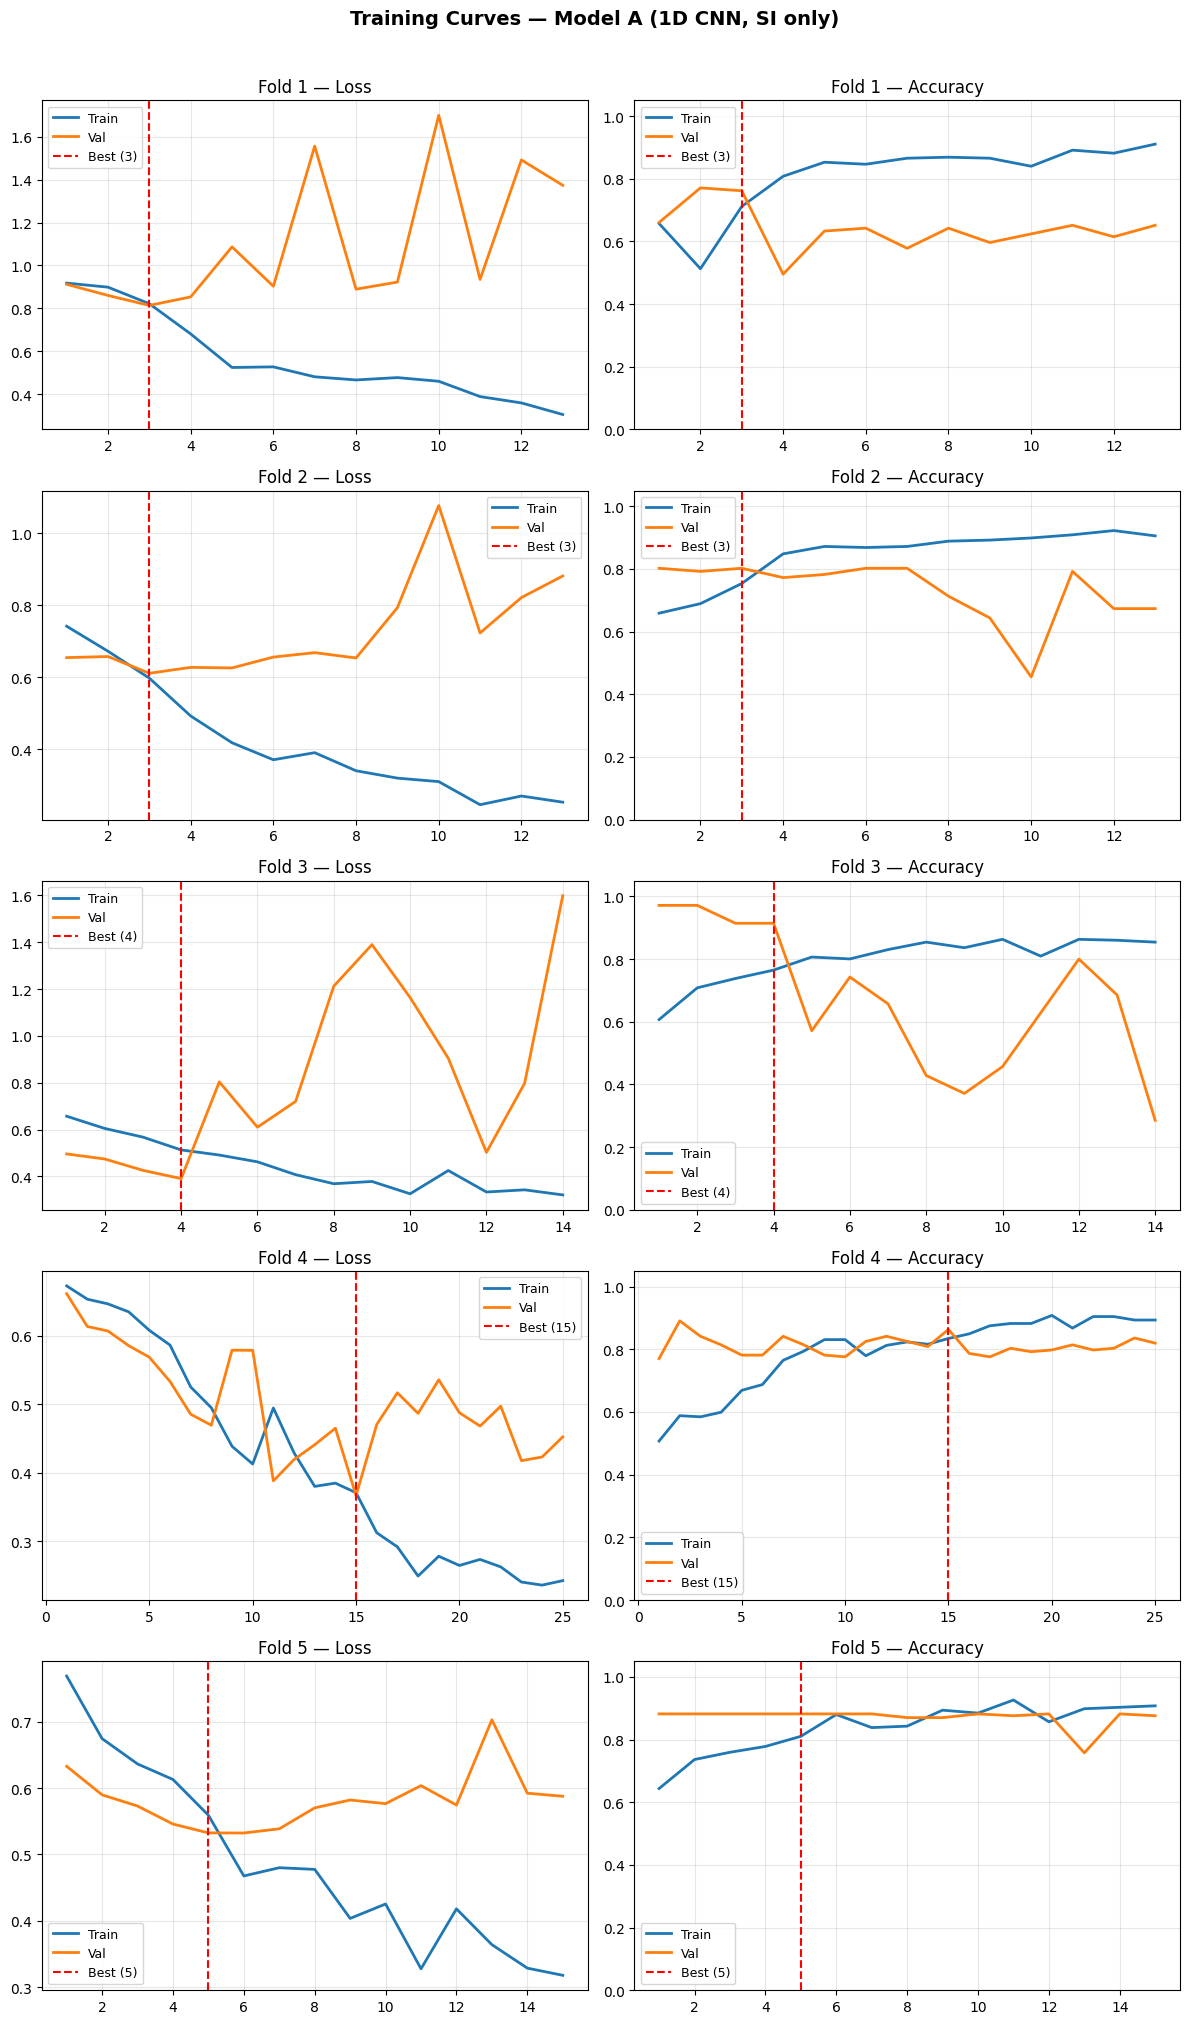

In [64]:
fig, axes = plt.subplots(nrows=N_FOLDS, ncols=2, figsize=(12, 4 * N_FOLDS))
fig.suptitle('Training Curves — Model A (1D CNN, SI only)', fontsize=14, fontweight='bold', y=1.01)

for i, r in enumerate(fold_results):
    h  = r['history']
    be = r['best_epoch']
    ep = range(1, len(h['train_loss']) + 1)

    ax_l = axes[i][0]
    ax_l.plot(ep, h['train_loss'], label='Train', lw=2)
    ax_l.plot(ep, h['val_loss'],   label='Val',   lw=2)
    ax_l.axvline(be + 1, color='red', ls='--', lw=1.5, label=f'Best ({be+1})')
    ax_l.set_title(f'Fold {r["fold"]} — Loss'); ax_l.legend(fontsize=9); ax_l.grid(alpha=0.3)

    ax_a = axes[i][1]
    ax_a.plot(ep, h['train_acc'], label='Train', lw=2)
    ax_a.plot(ep, h['val_acc'],   label='Val',   lw=2)
    ax_a.axvline(be + 1, color='red', ls='--', lw=1.5, label=f'Best ({be+1})')
    ax_a.set_title(f'Fold {r["fold"]} — Accuracy'); ax_a.set_ylim([0, 1.05])
    ax_a.legend(fontsize=9); ax_a.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## Evaluation

In [65]:

# ── Collect predictions ───────────────────────────────────────────────────────
fold_probs   = []
fold_y_tests = []

for r in fold_results:
    model = r['model']; model.eval()
    te_loader = DataLoader(
        _make_ds(r['te_df']),
        batch_size=INFERENCE_BATCH_SIZE, shuffle=False,
        num_workers=N_DL_WORKERS, pin_memory=torch.cuda.is_available(),
        **({'prefetch_factor': _pf} if _pf else {}),
    )

    all_logits = []
    with torch.no_grad():
        for xb, _ in te_loader:
            xb = xb.to(DEVICE)
            with torch.cuda.amp.autocast(enabled=_use_amp):
                all_logits.append(model(xb).squeeze(1).cpu().float().numpy())

    logits = np.concatenate(all_logits)
    probs  = 1 / (1 + np.exp(-logits))
    fold_probs.append(np.atleast_1d(probs))
    fold_y_tests.append(r['te_df']['label'].values.astype(int))

print(f'Collected predictions from {len(fold_probs)} folds.')


Collected predictions from 5 folds.


In [66]:

# ── Per-fold metrics ──────────────────────────────────────────────────────────
print('\n' + '=' * 70)
print('SUMMARY — Model A (1D CNN · SI 5-Block CV)')
print('=' * 70)

fold_summary = []
for i, (probs, y_true, r) in enumerate(zip(fold_probs, fold_y_tests, fold_results), start=1):
    fpr, tpr, thresholds = roc_curve(y_true, probs)
    j_idx  = np.argmax(tpr - fpr)
    thresh = float(thresholds[j_idx])

    preds          = (probs >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    sens  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec  = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    acc   = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
    # Macro F1: average of F1 for each class
    f1_tb      = 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) > 0 else 0.0
    f1_healthy = 2*tn / (2*tn + fn + fp) if (2*tn + fn + fp) > 0 else 0.0
    f1_macro   = (f1_tb + f1_healthy) / 2
    auroc = roc_auc_score(y_true, probs)
    auprc = average_precision_score(y_true, probs)

    fold_summary.append({
        'Fold': i, 'AUROC': f'{auroc:.4f}', 'AUPRC': f'{auprc:.4f}',
        'Sensitivity': f'{sens:.3f}', 'Specificity': f'{spec:.3f}',
        'F1-Macro': f'{f1_macro:.3f}', 'Acc': f'{acc:.3f}',
        'Threshold': f'{thresh:.4f}', 'Best Epoch': r['best_epoch'] + 1,
        '_auroc': auroc, '_auprc': auprc, '_sens': sens, '_spec': spec,
        '_f1_macro': f1_macro, '_acc': acc,
    })

cols = ['Fold', 'AUROC', 'AUPRC', 'Sensitivity', 'Specificity', 'F1-Macro', 'Acc', 'Threshold', 'Best Epoch']
print(pd.DataFrame(fold_summary)[cols].to_string(index=False))

aurocs    = [r['_auroc']    for r in fold_summary]
auprcs    = [r['_auprc']    for r in fold_summary]
senss     = [r['_sens']     for r in fold_summary]
specs     = [r['_spec']     for r in fold_summary]
f1_macros = [r['_f1_macro'] for r in fold_summary]
accs      = [r['_acc']      for r in fold_summary]

print(f'\nMean AUROC       : {np.mean(aurocs):.4f} ± {np.std(aurocs):.4f}')
print(f'Mean AUPRC       : {np.mean(auprcs):.4f} ± {np.std(auprcs):.4f}')
print(f'Mean Sensitivity : {np.mean(senss):.3f} ± {np.std(senss):.3f}')
print(f'Mean Specificity : {np.mean(specs):.3f} ± {np.std(specs):.3f}')
print(f'Mean F1 (Macro)  : {np.mean(f1_macros):.3f} ± {np.std(f1_macros):.3f}')
print(f'Mean Accuracy    : {np.mean(accs):.3f} ± {np.std(accs):.3f}')

summary_json = {'model': 'model_a_1d_cnn_si_cv', 'folds': [], 'mean': {}}
for r in fold_summary:
    summary_json['folds'].append({
        'fold': r['Fold'], 'auroc': r['_auroc'], 'auprc': r['_auprc'],
        'sensitivity': r['_sens'], 'specificity': r['_spec'],
        'f1_macro': r['_f1_macro'], 'accuracy': r['_acc'],
        'best_epoch': int(r['Best Epoch']),
    })
summary_json['mean'] = {
    'auroc': float(np.mean(aurocs)), 'auprc': float(np.mean(auprcs)),
    'sensitivity': float(np.mean(senss)), 'specificity': float(np.mean(specs)),
    'f1_macro': float(np.mean(f1_macros)), 'accuracy': float(np.mean(accs)),
}
with open(f'{OUTPUT_DIR}/summary_model_a.json', 'w') as f:
    json.dump(summary_json, f, indent=2)
print(f'\nSaved to {OUTPUT_DIR}/summary_model_a.json')



SUMMARY — Model A (1D CNN · SI 5-Block CV)
 Fold  AUROC  AUPRC Sensitivity Specificity F1-Macro   Acc Threshold  Best Epoch
    1 0.5726 0.6441       0.310       0.905    0.569 0.607    0.5171           3
    2 0.8551 0.6948       0.919       0.722    0.783 0.789    0.2713           3
    3 0.9417 0.6059       1.000       0.858    0.813 0.879    0.1791           4
    4 0.8680 0.5857       0.800       0.840    0.687 0.836    0.1695          15
    5 0.4227 0.6237       0.880       0.195    0.522 0.653    0.2282           5

Mean AUROC       : 0.7320 ± 0.1993
Mean AUPRC       : 0.6308 ± 0.0374
Mean Sensitivity : 0.782 ± 0.245
Mean Specificity : 0.704 ± 0.261
Mean F1 (Macro)  : 0.675 ± 0.114
Mean Accuracy    : 0.753 ± 0.105

Saved to ../output_model_a/summary_model_a.json


### ROC Curves & Confusion Matrices

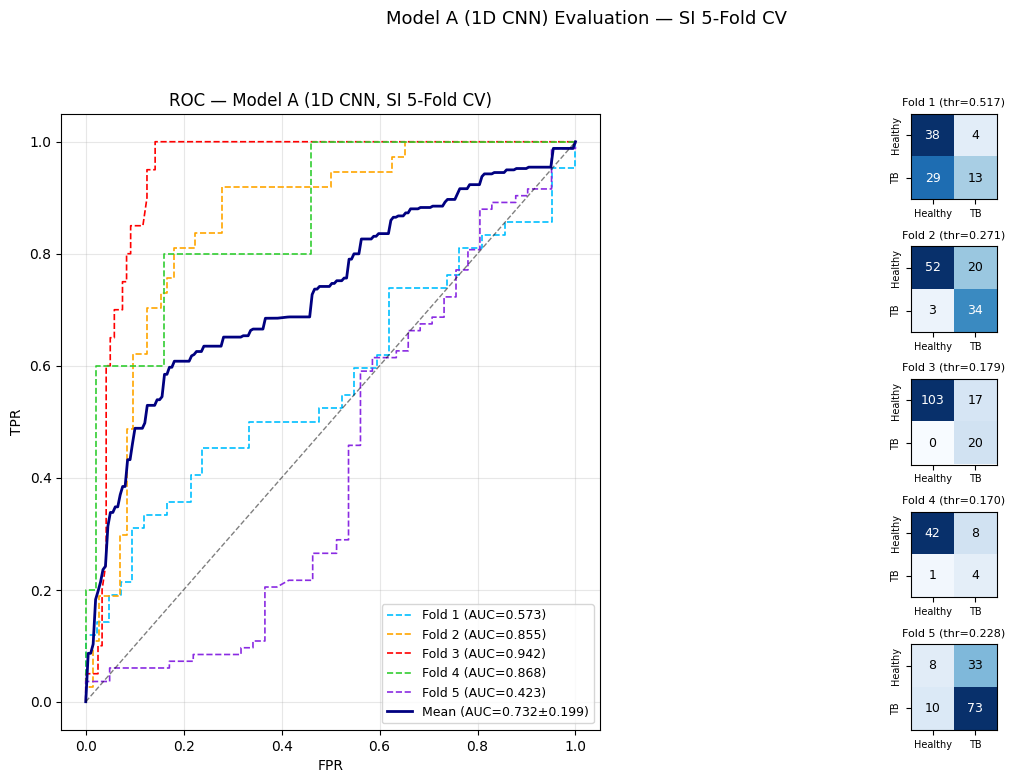

In [67]:
FOLD_COLORS = ['#00BFFF', '#FFA500', '#FF0000', '#32CD32', '#8A2BE2']
mean_fpr = np.linspace(0, 1, 200)
fold_fprs, fold_tprs, fold_aucs = [], [], []

for y_true, probs in zip(fold_y_tests, fold_probs):
    fpr, tpr, _ = roc_curve(y_true, probs)
    fold_fprs.append(fpr); fold_tprs.append(tpr); fold_aucs.append(auc(fpr, tpr))

interp_tprs = [np.interp(mean_fpr, f, t) for f, t in zip(fold_fprs, fold_tprs)]
mean_tpr    = np.mean(interp_tprs, axis=0); mean_tpr[0] = 0.0
mean_auc    = auc(mean_fpr, mean_tpr); std_auc = np.std(fold_aucs)

fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1.4, 1], wspace=0.35)

ax_roc = fig.add_subplot(gs[0])
for i, (fpr, tpr, a) in enumerate(zip(fold_fprs, fold_tprs, fold_aucs)):
    ax_roc.plot(fpr, tpr, color=FOLD_COLORS[i], lw=1.2, ls='--',
                label=f'Fold {i+1} (AUC={a:.3f})')
ax_roc.plot(mean_fpr, mean_tpr, color='navy', lw=2,
            label=f'Mean (AUC={mean_auc:.3f}±{std_auc:.3f})')
ax_roc.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
ax_roc.set_title('ROC — Model A (1D CNN, SI 5-Fold CV)'); ax_roc.legend(fontsize=9)
ax_roc.grid(alpha=0.3)

gs_cm = gridspec.GridSpecFromSubplotSpec(N_FOLDS, 1, subplot_spec=gs[1], hspace=0.55)
for i, (y_true, probs) in enumerate(zip(fold_y_tests, fold_probs)):
    fpr, tpr, ths = roc_curve(y_true, probs)
    thresh = float(ths[np.argmax(tpr - fpr)])
    preds = (probs >= thresh).astype(int)
    cm = confusion_matrix(y_true, preds)
    ax = fig.add_subplot(gs_cm[i])
    ax.imshow(cm, cmap=plt.cm.Blues, vmin=0)
    ax.set_title(f'Fold {i+1} (thr={thresh:.3f})', fontsize=8)
    ax.set_xticks([0,1]); ax.set_xticklabels(['Healthy','TB'], fontsize=7)
    ax.set_yticks([0,1]); ax.set_yticklabels(['Healthy','TB'], fontsize=7, rotation=90, va='center')
    mid = cm.max() / 2
    for r_i in range(2):
        for c_i in range(2):
            ax.text(c_i, r_i, str(cm[r_i, c_i]), ha='center', va='center', fontsize=9,
                    color='white' if cm[r_i, c_i] > mid else 'black')

plt.suptitle('Model A (1D CNN) Evaluation — SI 5-Fold CV', fontsize=13, y=1.01)
plt.savefig(f'{OUTPUT_DIR}/roc_cm_model_a.png', dpi=150, bbox_inches='tight')
plt.show()


### False Negative (FN) Error Analysis — Missed TB Segments

In [68]:

# ── False Negative (FN) Error Analysis ─────────────────────────────────────────
print('\n' + '='*80)
print('FALSE NEGATIVE (FN) ERROR ANALYSIS — Missed TB Segments')
print('='*80)

for i, r in enumerate(fold_results):
    fold_num = r['fold']
    model    = r['model']
    model.eval()

    te_df = r['te_df']   # per-fold disjoint SI test subset

    te_loader = DataLoader(
        _make_ds(te_df),
        batch_size=INFERENCE_BATCH_SIZE, shuffle=False,
        num_workers=N_DL_WORKERS, pin_memory=torch.cuda.is_available(),
        **({'prefetch_factor': _pf} if _pf else {}),
    )

    all_logits = []
    with torch.no_grad():
        for xb, _ in te_loader:
            xb = xb.to(DEVICE)
            with torch.cuda.amp.autocast(enabled=_use_amp):
                all_logits.append(model(xb).squeeze(1).cpu().float().numpy())

    logits = np.concatenate(all_logits)
    probs  = 1 / (1 + np.exp(-logits))
    y_true = te_df['label'].values.astype(int)

    fpr_f, tpr_f, thresholds_f = roc_curve(y_true, probs)
    thresh = float(thresholds_f[np.argmax(tpr_f - fpr_f)])
    preds  = (probs >= thresh).astype(int)

    fn_mask = (y_true == 1) & (preds == 0)
    fn_df   = te_df[fn_mask][['subject_id', 'file_path', 'label']].copy()
    fn_df['prob'] = np.round(probs[fn_mask], 4)
    fn_df['pred'] = 0

    total_tb = (y_true == 1).sum()
    print(f'\n--- Fold {fold_num} | Threshold: {thresh:.4f} | FN: {fn_mask.sum()} / {total_tb} TB segments ---')
    if fn_mask.sum() > 0:
        print(fn_df.to_string(index=False))
    else:
        print('  No false negatives in this fold.')

print(f'\n{"="*80}')



FALSE NEGATIVE (FN) ERROR ANALYSIS — Missed TB Segments

--- Fold 1 | Threshold: 0.5171 | FN: 29 / 42 TB segments ---
subject_id                                                 file_path  label   prob  pred
       008 ../data_root/Cough_sounds_patients_with_ptb/008_02-03.wav      1 0.3276     0
       008 ../data_root/Cough_sounds_patients_with_ptb/008_11-04.wav      1 0.5119     0
       008 ../data_root/Cough_sounds_patients_with_ptb/008_11-03.wav      1 0.4644     0
       008 ../data_root/Cough_sounds_patients_with_ptb/008_02-04.wav      1 0.3275     0
       008 ../data_root/Cough_sounds_patients_with_ptb/008_11-01.wav      1 0.4092     0
       008 ../data_root/Cough_sounds_patients_with_ptb/008_12-02.wav      1 0.4939     0
       008 ../data_root/Cough_sounds_patients_with_ptb/008_12-04.wav      1 0.3300     0
       008 ../data_root/Cough_sounds_patients_with_ptb/008_03-01.wav      1 0.3776     0
       008 ../data_root/Cough_sounds_patients_with_ptb/008_02-01.wav      1 0.29